1. На основе учебного ноутбука, проведите финальную подготовку данных. измените количество сегментирующих классов с `16` на `7`
 - 0_класс - FLOOR
 - 1_класс - CEILING
 - 2_класс - WALL
 - 3_класс - APERTURE, DOOR, WINDOW
 - 4_класс - COLUMN, RAILINGS, LADDER
 - 5_класс - INVENTORY
 - 6_класс - LAMP, WIRE, BEAM, EXTERNAL, BATTERY,
PEOPLE

2. Реализуйте сегментацию базы Стройка на основе модели `PSPnet`. Статья для изучения [Pyramid Scene Parsing Network](https://hszhao.github.io/projects/pspnet/) .


**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

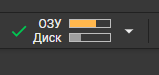


Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

In [ ]:
import os
import time
import random
import gc
import zipfile

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import gdown

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

plt.rcParams["axes.grid"] = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Устройство:", device)

In [ ]:
DATA_URL = "https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip"
ARCHIVE_NAME = "construction_256x192.zip"

if not os.path.exists(ARCHIVE_NAME):
    gdown.download(DATA_URL, ARCHIVE_NAME, quiet=False)

if not (os.path.exists("train") and os.path.exists("val")):
    with zipfile.ZipFile(ARCHIVE_NAME, "r") as archive:
        archive.extractall(".")

print("Данные готовы")

In [ ]:
IMG_HEIGHT = 256
IMG_WIDTH = 192
NUM_CLASSES = 7

TRAIN_DIR = "train"
VAL_DIR = "val"

CLASS_COLORS = {
    "floor": (100, 100, 100),
    "ceiling": (0, 0, 100),
    "wall": (0, 100, 0),
    "column": (100, 0, 0),
    "aperture": (0, 100, 100),
    "door": (100, 0, 100),
    "window": (100, 100, 0),
    "external": (200, 200, 200),
    "railings": (0, 200, 0),
    "battery": (200, 0, 0),
    "people": (0, 200, 200),
    "ladder": (0, 0, 200),
    "inventory": (200, 0, 200),
    "lamp": (200, 200, 0),
    "wire": (0, 100, 200),
    "beam": (100, 0, 200),
}

LABEL_GROUPS = {
    0: ["floor"],
    1: ["ceiling"],
    2: ["wall"],
    3: ["aperture", "door", "window"],
    4: ["column", "railings", "ladder"],
    5: ["inventory"],
    6: ["lamp", "wire", "beam", "external", "battery", "people"],
}


def collect_files(base_dir, subfolder):
    folder = os.path.join(base_dir, subfolder)
    return [os.path.join(folder, name) for name in sorted(os.listdir(folder))]


def load_rgb_image(file_path):
    img = Image.open(file_path).convert("RGB")
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr.transpose(2, 0, 1)


def load_mask_as_labels(file_path):
    mask = Image.open(file_path).convert("RGB")
    mask = mask.resize((IMG_WIDTH, IMG_HEIGHT), resample=Image.NEAREST)
    rgb = np.asarray(mask)
    labels = np.zeros((IMG_HEIGHT, IMG_WIDTH), dtype=np.int64)

    for class_id, names in LABEL_GROUPS.items():
        for item in names:
            color = CLASS_COLORS[item]
            labels[np.all(rgb == color, axis=-1)] = class_id

    return labels


class ConstructionSegmentationDataset(Dataset):
    def __init__(self, base_dir):
        self.image_paths = collect_files(base_dir, "original")
        self.mask_paths = collect_files(base_dir, "segment")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        x = load_rgb_image(self.image_paths[index])
        y = load_mask_as_labels(self.mask_paths[index])
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


train_dataset = ConstructionSegmentationDataset(TRAIN_DIR)
val_dataset = ConstructionSegmentationDataset(VAL_DIR)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print("Обучающих изображений:", len(train_dataset))
print("Проверочных изображений:", len(val_dataset))

In [ ]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class PyramidPooling(nn.Module):
    def __init__(self, in_channels, pool_sizes=(1, 2, 3, 6), branch_channels=48):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.AdaptiveAvgPool2d((size, size)),
                nn.Conv2d(in_channels, branch_channels, kernel_size=1),
                nn.BatchNorm2d(branch_channels),
                nn.ReLU(inplace=True)
            )
            for size in pool_sizes
        ])

    def forward(self, x):
        h, w = x.shape[2], x.shape[3]
        outputs = [x]

        for branch in self.branches:
            pooled = branch(x)
            resized = F.interpolate(pooled, size=(h, w), mode="bilinear", align_corners=False)
            outputs.append(resized)

        return torch.cat(outputs, dim=1)


class PSPNetTorch(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.encoder = nn.Sequential(
            ConvBNReLU(3, 48),
            ConvBNReLU(48, 48),
            nn.MaxPool2d(2),
            ConvBNReLU(48, 96),
            nn.MaxPool2d(2),
            ConvBNReLU(96, 192),
            nn.MaxPool2d(2)
        )

        self.pyramid = PyramidPooling(192, pool_sizes=(1, 2, 3, 6), branch_channels=48)
        self.decoder = ConvBNReLU(192 + 4 * 48, 192)
        self.classifier = nn.Conv2d(192, num_classes, kernel_size=1)

    def forward(self, x):
        original_size = x.shape[2:]
        x = self.encoder(x)
        x = self.pyramid(x)
        x = self.decoder(x)
        x = F.interpolate(x, size=original_size, mode="bilinear", align_corners=False)
        return self.classifier(x)


model = PSPNetTorch(num_classes=NUM_CLASSES).to(device)
model

In [ ]:
def pixel_accuracy(logits, masks):
    predicted = torch.argmax(logits, dim=1)
    correct = (predicted == masks).sum().item()
    total = masks.numel()
    return correct / total


def run_epoch(net, loader, loss_fn, optimizer=None):
    training = optimizer is not None
    net.train() if training else net.eval()

    total_loss = 0.0
    total_acc = 0.0
    batches = 0

    with torch.set_grad_enabled(training):
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            if training:
                optimizer.zero_grad()

            outputs = net(images)
            loss = loss_fn(outputs, masks)

            if training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_acc += pixel_accuracy(outputs, masks)
            batches += 1

    return total_loss / batches, total_acc / batches


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

history = {
    "loss": [],
    "accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

start = time.time()

for epoch in range(15):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Эпоха {epoch + 1:02d}/15 | "
        f"loss={train_loss:.4f} | accuracy={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_accuracy={val_acc:.4f}"
    )

    gc.collect()

elapsed = round((time.time() - start) / 60, 2)
print("Время обучения:", elapsed, "мин.")

In [ ]:
def show_training_history(history_dict):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].plot(history_dict["accuracy"], label="Обучающая выборка", linewidth=2.5)
    axes[0].plot(history_dict["val_accuracy"], label="Проверочная выборка", linewidth=2.5)
    axes[0].set_title("Точность модели")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history_dict["loss"], label="Обучающая выборка", linewidth=2.5)
    axes[1].plot(history_dict["val_loss"], label="Проверочная выборка", linewidth=2.5)
    axes[1].set_title("Ошибка модели")
    axes[1].set_xlabel("Эпоха")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def show_segmentation_example(net, dataset):
    idx = random.randint(0, len(dataset) - 1)
    image_tensor, mask_tensor = dataset[idx]

    net.eval()
    with torch.no_grad():
        logits = net(image_tensor.unsqueeze(0).to(device))
        predicted = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    image_np = image_tensor.permute(1, 2, 0).numpy()
    mask_np = mask_tensor.numpy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(image_np)
    axes[0].set_title("Исходное изображение")
    axes[0].axis("off")

    axes[1].imshow(mask_np, cmap="tab10", vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title("Правильная маска")
    axes[1].axis("off")

    axes[2].imshow(predicted, cmap="tab10", vmin=0, vmax=NUM_CLASSES - 1)
    axes[2].set_title("Предсказание PSPNet")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


show_training_history(history)
show_segmentation_example(model, val_dataset)